# Linear Regression จาก Scratch — บทสรุป Phase 01 (เรียนด้วย NumPy ทีละขั้น)

**ระดับ:** ปานกลาง–สูง • **เวลาประมาณ:** 90–120 นาที แบ่งเรียนได้ 2–3 รอบ • **ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้เป็น **capstone ของ Phase 01** — นำแนวคิดจากทุก notebook ก่อนหน้ามาประกอบกันเป็น
linear regression ที่ใช้งานได้จริง: vector/matrix ([01](01_vectors_and_matrices.ipynb)),
determinant/inverse/solve ([02](02_matrix_operations.ipynb)), eigenvalue/SVD/pseudo-inverse
([03](03_eigenvalues_and_svd.ipynb)) และ gradient descent ([04](04_gradients_intuition.ipynb))
โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างขึ้นใหม่สำหรับ notebook นี้

**ก่อนเริ่ม:** ควรผ่าน notebook 01–04 ในโฟลเดอร์นี้มาก่อน เลือก kernel `.venv` ของโครงการ
แล้วใช้ **Restart Kernel → Run All** โค้ดใช้เฉพาะแพ็กเกจที่มีในโครงการ ไม่ต้องดาวน์โหลดข้อมูล

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. linear regression แก้ได้ด้วย closed-form กี่วิธี และแต่ละวิธีเชื่อมกับเนื้อหา notebook ไหนบ้าง
2. gradient descent สำหรับ linear regression เขียนเป็นฟังก์ชันที่ใช้ซ้ำได้อย่างไร
3. **ทำไม gradient descent ลู่เข้าเร็วหรือช้า** โดยอธิบายผ่านการ diagonalize Hessian ของ loss function
4. condition number ของข้อมูลจริงส่งผลต่อการลู่เข้าอย่างไร และทำไม feature scaling ช่วยได้
5. เขียน `LinearRegressionScratch` ที่ fit ได้ทั้งสองวิธี แล้วเทียบผลกับ `sklearn.linear_model.LinearRegression`

**เส้นทาง:** ส่วน 1–2 ทบทวนโมเดล → ส่วน 3–4 closed-form และ gradient descent →
ส่วน 5–6 **ทำไม gradient descent ลู่เข้าเร็ว/ช้า (eigenvalues + diagonalization)** →
ส่วน 7 mini-project → ส่วน 8–10 สรุป Phase 01 และแบบฝึกหัด

## 1. เตรียมเครื่องมือ

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from sklearn.linear_model import LinearRegression

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Linear Regression Model: ทบทวนสมการ

$$\hat y = X\theta, \qquad X \in \mathbb{R}^{n\times(d+1)} \text{ (รวมคอลัมน์ 1 สำหรับ bias)},
\qquad L(\theta) = \frac{1}{n}\|X\theta-y\|_2^2$$

โมเดลและ loss function นี้เหมือนกับที่ใช้ใน notebook 01 (mini-project) และ 04 (gradient descent)
ทุกประการ — สิ่งที่ notebook นี้เพิ่มเข้ามาคือ **การเข้าใจว่าทำไมแต่ละวิธีแก้ปัญหาทำงานอย่างที่มันทำงาน**

## 3. หาคำตอบแบบ Closed-form: สามวิธี หนึ่งคำตอบ

จาก notebook 02 และ 03 เรามีวิธี closed-form ถึงสามวิธีสำหรับหาค่าต่ำสุดของ $L(\theta)$:

1. **Normal equation:** $\theta = (X^\top X)^{-1}X^\top y$ — แก้ด้วย `np.linalg.solve` (notebook 02)
2. **Pseudo-inverse ผ่าน SVD:** $\theta = X^+y = V\Sigma^+U^\top y$ — `np.linalg.pinv` (notebook 03)
3. **`np.linalg.lstsq`** — ใช้ SVD ภายในเช่นกัน แต่เสถียรกว่าเมื่อ $X$ เกือบ singular

ทั้งสามวิธีควรให้คำตอบเดียวกัน (ในทางคณิตศาสตร์เป็นสูตรเดียวกัน เขียนต่างกันเท่านั้น)

In [2]:
rng = np.random.default_rng(SEED)
n, d = 60, 3
X_raw = rng.uniform(1, 10, size=(n, d))
true_theta = np.array([2.0, -1.0, 0.5])
true_b = 3.0
y = X_raw @ true_theta + true_b + rng.normal(0, 0.3, n)
X_design = np.column_stack([np.ones(n), X_raw])

theta_normal_eq = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)
theta_pinv = np.linalg.pinv(X_design) @ y
theta_lstsq, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)

print("theta (normal equation):", theta_normal_eq)
print("theta (pseudo-inverse):  ", theta_pinv)
print("theta (lstsq):           ", theta_lstsq)
np.testing.assert_allclose(theta_normal_eq, theta_pinv, atol=1e-8)
np.testing.assert_allclose(theta_normal_eq, theta_lstsq, atol=1e-8)
print("ทั้งสามวิธีให้คำตอบตรงกัน (ต่างแค่วิธีคำนวณภายใน)")

theta (normal equation): [ 3.     2.019 -0.997  0.48 ]
theta (pseudo-inverse):   [ 3.     2.019 -0.997  0.48 ]
theta (lstsq):            [ 3.     2.019 -0.997  0.48 ]
ทั้งสามวิธีให้คำตอบตรงกัน (ต่างแค่วิธีคำนวณภายใน)


## 4. Gradient Descent: เขียนเป็นฟังก์ชันที่ใช้ซ้ำได้

จาก notebook 04 นำ MSE gradient มาเขียนเป็นฟังก์ชัน `fit_gradient_descent` ที่ใช้ซ้ำได้ตลอด notebook นี้
รับ $X$ (ยังไม่ต่อคอลัมน์ 1), $y$, learning rate และจำนวน epoch แล้วคืน $\theta$ กับ loss history

In [3]:
def add_bias_column(X):
    return np.column_stack([np.ones(len(X)), X])


def fit_gradient_descent(X, y, lr, epochs):
    Xd = add_bias_column(X)
    theta = np.zeros(Xd.shape[1])
    loss_history = []
    for _ in range(epochs):
        residual = Xd @ theta - y
        loss_history.append(np.mean(residual**2))
        grad = (2.0 / len(y)) * (Xd.T @ residual)
        theta = theta - lr * grad
    return theta, np.array(loss_history)


theta_gd, loss_history = fit_gradient_descent(X_raw, y, lr=0.01, epochs=2000)
print("theta (gradient descent):", theta_gd)
print("theta (closed-form):     ", theta_normal_eq)
per_parameter_error = np.abs(theta_gd - theta_normal_eq)
print("ความคลาดเคลื่อนต่อพารามิเตอร์:", per_parameter_error)
assert per_parameter_error.max() < 0.5  # ใกล้เคียงแต่ยังไม่ลู่เข้าเป๊ะหลัง 2000 epoch

theta (gradient descent): [ 2.784  2.033 -0.988  0.493]
theta (closed-form):      [ 3.     2.019 -0.997  0.48 ]
ความคลาดเคลื่อนต่อพารามิเตอร์: [0.217 0.015 0.009 0.013]


**สังเกตสิ่งที่น่าสงสัย:** หลัง 2000 epoch ค่า $\theta_0$ (bias) ยังห่างจากคำตอบ closed-form
พอสมควร ในขณะที่ $\theta_2,\theta_3$ เกือบตรงเป๊ะแล้ว — **ทำไมพารามิเตอร์บางตัวลู่เข้าเร็วกว่าตัวอื่น?**
ส่วน 5 จะตอบคำถามนี้อย่างแม่นยำ โดย diagonalize Hessian ตัวเดียวกันนี้เอง

## 5. ทำไม Gradient Descent ลู่เข้าเร็วหรือช้า: Diagonalize the Hessian

$L(\theta)=\frac1n\|X\theta-y\|_2^2$ เป็นฟังก์ชันกำลังสอง (quadratic) มี **Hessian คงที่**:

$$H = \nabla^2 L(\theta) = \frac{2}{n}X^\top X \qquad \text{(สมมาตรและกึ่งบวกแน่นอนเสมอ)}$$

เนื่องจาก $H$ สมมาตร จึง diagonalize ได้เสมอ (notebook 03): $H = Q\Lambda Q^\top$ โดย $Q$ คือเมทริกซ์
eigenvector ($Q^\top Q=I$) และ $\Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_d)$ คือ eigenvalue

**นี่คือจุดที่ diagonalization "ทำให้ปัญหาง่ายขึ้น" ตามที่บทความอ้างอิงบอกไว้จริงๆ:** ถ้าเปลี่ยนพิกัดเป็น
$z=Q^\top\theta$ (หมุนแกนไปตามทิศทาง eigenvector) การอัปเดต gradient descent ในพิกัดใหม่จะ**แยกอิสระ
ต่อกันในแต่ละแกน** เหมือนปัญหา 1 มิติในบทเรียน 04 ทุกประการ:

$$z_{t+1,i} = (1-\eta\lambda_i)\,z_{t,i} \quad\Rightarrow\quad z_{t,i} = (1-\eta\lambda_i)^t\,z_{0,i}$$

แต่ละทิศทาง eigenvector มี "อัตราการลู่เข้า" ของตัวเอง กำหนดโดย eigenvalue ของมัน — ทิศทางที่มี
eigenvalue มาก (โค้งชัน) ลู่เข้าเร็ว ทิศทางที่มี eigenvalue น้อย (โค้งแบน) ลู่เข้าช้า

อ้างอิง: [Wikipedia — Eigenvalues and eigenvectors](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors),
[statlect — Matrix diagonalization](https://www.statlect.com/matrix-algebra/matrix-diagonalization)

In [4]:
# สร้าง Hessian ที่ควบคุม eigenvalue ได้ตรงๆ เพื่อตรวจสอบทฤษฎีอย่างแม่นยำ
Q_random, _ = np.linalg.qr(rng.normal(size=(2, 2)))  # เมทริกซ์ orthogonal สุ่ม
lambda_max, lambda_min = 10.0, 1.0
H = Q_random @ np.diag([lambda_max, lambda_min]) @ Q_random.T
H = (H + H.T) / 2  # บังคับให้สมมาตรพอดี (กันความคลาดเคลื่อนจาก floating-point)

eigvals, eigvecs = np.linalg.eigh(H)
order = np.argsort(eigvals)[::-1]
eigvals, Q = eigvals[order], eigvecs[:, order]
print("eigenvalues ของ H:", eigvals)
np.testing.assert_allclose(Q @ np.diag(eigvals) @ Q.T, H, atol=1e-8)


def gd_on_quadratic(H, theta0, lr, steps):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - lr * (H @ theta)  # gradient ของ (1/2)θᵀHθ คือ Hθ
        path.append(theta.copy())
    return np.array(path)


theta0 = np.array([5.0, 5.0])
lr = 0.15
steps = 20
actual_path = gd_on_quadratic(H, theta0, lr, steps)

# ทำนายเส้นทางด้วยสูตรปิด (closed-form) ผ่านการ diagonalize แล้วเทียบกับ gradient descent จริง
z0 = Q.T @ theta0
t_arr = np.arange(steps + 1)
z_predicted = np.stack([z0[i] * (1 - lr * eigvals[i]) ** t_arr for i in range(2)], axis=1)
theta_predicted = z_predicted @ Q.T

np.testing.assert_allclose(actual_path, theta_predicted, atol=1e-6)
print("เส้นทางที่ทำนายจากสูตร diagonalization ตรงกับ gradient descent จริงทุกก้าว (ไม่ใช่แค่ประมาณ)")

eigenvalues ของ H: [10.  1.]
เส้นทางที่ทำนายจากสูตร diagonalization ตรงกับ gradient descent จริงทุกก้าว (ไม่ใช่แค่ประมาณ)


lr ต้องน้อยกว่า 2/λ_max = 0.2 จึงจะลู่เข้าได้ทุกทิศทาง
lr=0.15 (< 0.2): ลู่เข้า, |θ| สุดท้าย = 0.0001928
lr=0.25 (> 0.2): ลู่ออก,  |θ| สุดท้าย = 2.297e+11


/var/folders/h_/n_3fs8zd6qs13gg2qhy4yzw40000gn/T/ipykernel_19540/1170628362.py:29: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Tahoma.
  plt.tight_layout()
/var/folders/h_/n_3fs8zd6qs13gg2qhy4yzw40000gn/T/ipykernel_19540/1170628362.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Tahoma.
  plt.tight_layout()
/Users/ittichaib/Documents/GitHub/ml-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ittichaib/Documents/GitHub/ml-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


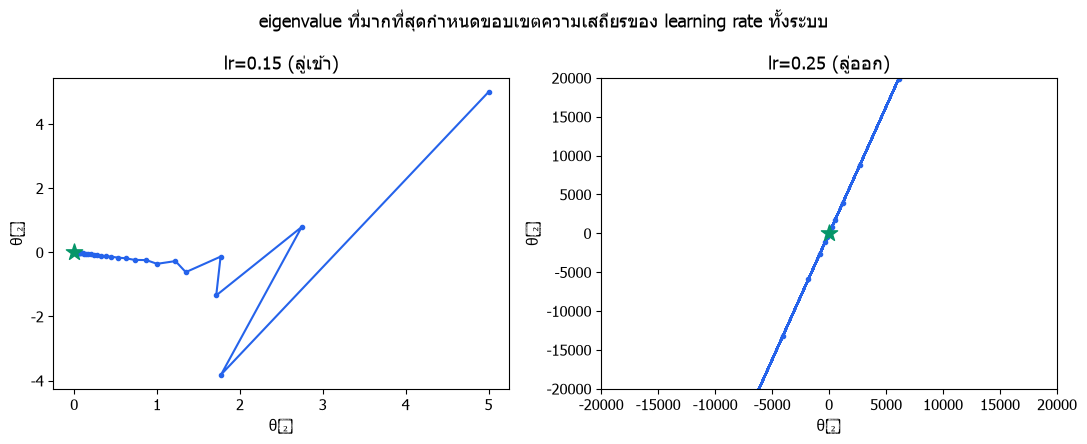

In [5]:
# ขอบเขตความเสถียร: lr ต้อง < 2/lambda_max ไม่เช่นนั้นทิศทางที่โค้งชันที่สุดจะลู่ออก
lr_max_stable = 2 / lambda_max
print(f"lr ต้องน้อยกว่า 2/λ_max = {lr_max_stable:g} จึงจะลู่เข้าได้ทุกทิศทาง")

path_converge = gd_on_quadratic(H, theta0, lr=0.15, steps=60)
path_diverge = gd_on_quadratic(H, theta0, lr=0.25, steps=60)
assert np.linalg.norm(path_converge[-1]) < np.linalg.norm(theta0)
assert np.linalg.norm(path_diverge[-1]) > np.linalg.norm(theta0) * 10
print(f"lr=0.15 (< {lr_max_stable:g}): ลู่เข้า, |θ| สุดท้าย = {np.linalg.norm(path_converge[-1]):.4g}")
print(f"lr=0.25 (> {lr_max_stable:g}): ลู่ออก,  |θ| สุดท้าย = {np.linalg.norm(path_diverge[-1]):.4g}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, path, title in zip(
    axes, [path_converge, path_diverge], ["lr=0.15 (ลู่เข้า)", "lr=0.25 (ลู่ออก)"]
):
    ax.plot(path[:, 0], path[:, 1], "o-", markersize=3, color="#2563eb")
    ax.scatter([0], [0], color="#059669", marker="*", s=150, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("θ₁")
    ax.set_ylabel("θ₂")
axes[1].set_xlim(-2e4, 2e4)
axes[1].set_ylim(-2e4, 2e4)
fig.suptitle(
    label(
        "eigenvalue ที่มากที่สุดกำหนดขอบเขตความเสถียรของ learning rate ทั้งระบบ",
        "The largest eigenvalue bounds the stable learning rate for the whole system",
    )
)
plt.tight_layout()
plt.show()

### กลับไปตอบคำถามจากส่วน 4: ทำไม $\theta_0$ ลู่เข้าช้ากว่าตัวอื่น

diagonalize Hessian จริงจากส่วน 3–4 ($H=\frac2n X_{design}^\top X_{design}$ ขนาด $4\times4$)
แล้วใช้สูตรเดียวกับด้านบนทำนายค่าความคลาดเคลื่อนของ gradient descent ที่ epoch 2000 เทียบกับที่รันจริง

In [6]:
H_real = (2.0 / n) * (X_design.T @ X_design)
eigvals_real, eigvecs_real = np.linalg.eigh(H_real)
order_real = np.argsort(eigvals_real)[::-1]
eigvals_real, Q_real = eigvals_real[order_real], eigvecs_real[:, order_real]
print("eigenvalues ของ H จริง (เรียงจากมากไปน้อย):", eigvals_real)

# เริ่มจาก theta=0 เหมือนใน fit_gradient_descent ส่วน 4 ดังนั้น error เริ่มต้นคือ 0 - theta_normal_eq
error0 = np.zeros(4) - theta_normal_eq
z0_real = Q_real.T @ error0
error_predicted_2000 = Q_real @ (z0_real * (1 - 0.01 * eigvals_real) ** 2000)
error_actual_2000 = theta_gd - theta_normal_eq
np.testing.assert_allclose(error_predicted_2000, error_actual_2000, atol=1e-8)
print("ความคลาดเคลื่อนที่ทำนายจาก diagonalization ตรงกับของจริงทุกตัวเลข")

print(
    f"ทิศทาง eigenvalue น้อยที่สุด ({eigvals_real.min():.4f}) เหลือความคลาดเคลื่อน "
    f"{(1 - 0.01 * eigvals_real.min()) ** 2000:.2%} หลัง 2000 epoch — นี่คือตัวการที่ทำให้ θ₀ ยังไม่ลู่เข้า"
)

theta_gd_long, _ = fit_gradient_descent(X_raw, y, lr=0.01, epochs=50_000)
print("theta หลังรันยาวขึ้นเป็น 50,000 epoch:", theta_gd_long)
np.testing.assert_allclose(theta_gd_long, theta_normal_eq, atol=1e-6)
print("รันนานพอ ทิศทางที่ช้าที่สุดก็ลู่เข้าจนเกือบเป๊ะในที่สุด — สอดคล้องกับที่ทฤษฎีทำนายไว้")

eigenvalues ของ H จริง (เรียงจากมากไปน้อย): [192.216  14.08   11.227   0.129]
ความคลาดเคลื่อนที่ทำนายจาก diagonalization ตรงกับของจริงทุกตัวเลข
ทิศทาง eigenvalue น้อยที่สุด (0.1287) เหลือความคลาดเคลื่อน 7.61% หลัง 2000 epoch — นี่คือตัวการที่ทำให้ θ₀ ยังไม่ลู่เข้า


theta หลังรันยาวขึ้นเป็น 50,000 epoch: [ 3.     2.019 -0.997  0.48 ]
รันนานพอ ทิศทางที่ช้าที่สุดก็ลู่เข้าจนเกือบเป๊ะในที่สุด — สอดคล้องกับที่ทฤษฎีทำนายไว้


## 6. Condition Number บนข้อมูลจริง: ทำไมต้อง Standardize Feature

**Condition number** ของ Hessian คือ $\kappa = \lambda_{\max}/\lambda_{\min}$ — ยิ่งค่านี้สูง
ยิ่งต้องเลือก learning rate เล็กมาก (ถูกจำกัดโดย $\lambda_{\max}$) ในขณะที่ทิศทาง $\lambda_{\min}$
ยังคงลู่เข้าช้ามาก นี่คือเหตุผลเชิงทฤษฎีของสิ่งที่สังเกตแบบ "ลองผิดลองถูก" ใน notebook 04:
ทำไม standardize feature ก่อน gradient descent ถึงช่วยได้มาก

เปรียบเทียบ $\kappa(H)$ ของข้อมูลบ้านจำลอง (แบบเดียวกับ notebook 04) ก่อนและหลัง standardize

In [7]:
rng = np.random.default_rng(SEED)
n2 = 200
area = rng.uniform(40, 200, n2)
bedrooms = rng.integers(1, 6, n2)
age = rng.integers(0, 31, n2)
X_house_raw = np.column_stack([area, bedrooms, age])
true_w = np.array([0.025, 0.30, -0.02])
true_b2 = 0.4
y_house = X_house_raw @ true_w + true_b2 + rng.normal(0, 0.12, n2)

X_house_design_raw = add_bias_column(X_house_raw)
mean_house = X_house_raw.mean(axis=0)
std_house = X_house_raw.std(axis=0)
X_house_scaled = (X_house_raw - mean_house) / std_house
X_house_design_scaled = add_bias_column(X_house_scaled)


def condition_number_of_hessian(X_design, n_samples):
    H_data = (2.0 / n_samples) * (X_design.T @ X_design)
    eig = np.linalg.eigvalsh(H_data)
    return eig.max() / eig[eig > 1e-12].min()


cond_raw = condition_number_of_hessian(X_house_design_raw, n2)
cond_scaled = condition_number_of_hessian(X_house_design_scaled, n2)
print(f"condition number ก่อน standardize: {cond_raw:,.0f}")
print(f"condition number หลัง standardize: {cond_scaled:.2f}")
assert cond_raw > cond_scaled * 10
print(
    "standardize ลด condition number ลงมหาศาล — เหตุผลที่ gradient descent ลู่เข้าเร็วขึ้นมากใน notebook 04"
)

condition number ก่อน standardize: 303,422
condition number หลัง standardize: 1.43
standardize ลด condition number ลงมหาศาล — เหตุผลที่ gradient descent ลู่เข้าเร็วขึ้นมากใน notebook 04


## 7. Mini-project: `LinearRegressionScratch`

ประกอบทุกอย่างเป็น class เดียวที่ fit ได้ทั้งสองวิธี แล้วเทียบผลกับ `sklearn.linear_model.LinearRegression`
บนข้อมูลบ้านจำลอง (standardize แล้ว จากส่วน 6) แบ่ง train/test ให้ยุติธรรม

MSE — closed-form: 0.01451, gradient descent: 0.01451, sklearn: 0.01451
closed-form ตรงกับ sklearn เป๊ะ และ gradient descent ลู่เข้าใกล้เคียงมาก


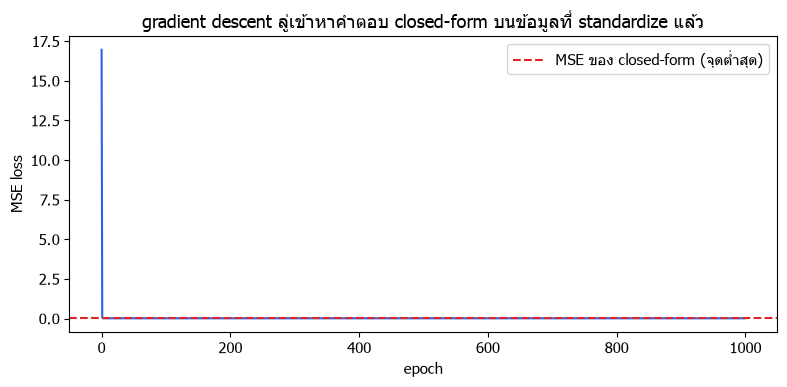

In [8]:
class LinearRegressionScratch:
    def __init__(self, method="closed_form", lr=0.5, epochs=1000):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.theta_ = None
        self.loss_history_ = []

    def fit(self, X, y):
        Xd = add_bias_column(X)
        if self.method == "closed_form":
            self.theta_ = np.linalg.solve(Xd.T @ Xd, Xd.T @ y)
        elif self.method == "gradient_descent":
            theta = np.zeros(Xd.shape[1])
            for _ in range(self.epochs):
                residual = Xd @ theta - y
                self.loss_history_.append(np.mean(residual**2))
                grad = (2.0 / len(y)) * (Xd.T @ residual)
                theta = theta - self.lr * grad
            self.theta_ = theta
        else:
            raise ValueError(f"unknown method: {self.method}")
        return self

    def predict(self, X):
        return add_bias_column(X) @ self.theta_


rng = np.random.default_rng(SEED)
idx = rng.permutation(n2)
train_idx, test_idx = idx[:150], idx[150:]
X_train, X_test = X_house_scaled[train_idx], X_house_scaled[test_idx]
y_train, y_test = y_house[train_idx], y_house[test_idx]

model_cf = LinearRegressionScratch(method="closed_form").fit(X_train, y_train)
model_gd = LinearRegressionScratch(method="gradient_descent", lr=0.5, epochs=1000).fit(
    X_train, y_train
)
sklearn_model = LinearRegression().fit(X_train, y_train)

pred_cf = model_cf.predict(X_test)
pred_gd = model_gd.predict(X_test)
pred_sklearn = sklearn_model.predict(X_test)
mse_cf = np.mean((pred_cf - y_test) ** 2)
mse_gd = np.mean((pred_gd - y_test) ** 2)
mse_sklearn = np.mean((pred_sklearn - y_test) ** 2)
print(
    f"MSE — closed-form: {mse_cf:.5f}, gradient descent: {mse_gd:.5f}, sklearn: {mse_sklearn:.5f}"
)

np.testing.assert_allclose(model_cf.theta_[1:], sklearn_model.coef_, atol=1e-6)
np.testing.assert_allclose(model_cf.theta_[0], sklearn_model.intercept_, atol=1e-6)
np.testing.assert_allclose(model_gd.theta_, model_cf.theta_, atol=1e-2)
print("closed-form ตรงกับ sklearn เป๊ะ และ gradient descent ลู่เข้าใกล้เคียงมาก")

fig, ax = plt.subplots()
ax.plot(model_gd.loss_history_, color="#2563eb")
ax.set_xlabel(label("epoch", "epoch"))
ax.set_ylabel("MSE loss")
ax.axhline(
    mse_cf,
    linestyle="--",
    color="#dc2626",
    label=label("MSE ของ closed-form (จุดต่ำสุด)", "closed-form MSE"),
)
ax.legend()
ax.set_title(
    label(
        "gradient descent ลู่เข้าหาคำตอบ closed-form บนข้อมูลที่ standardize แล้ว",
        "GD converges to the closed-form optimum",
    )
)
plt.tight_layout()
plt.show()

## 8. แผนที่เชื่อมแนวคิดกับงานจริง (สรุปทั้ง Phase 01)

| แนวคิด | Notebook | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|---|
| Vector / matrix / broadcasting | 01 | `X @ w`, `(X - mean) / std` | แทนข้อมูลและทำนายหลายตัวอย่างพร้อมกัน |
| Determinant / inverse / solve | 02 | `np.linalg.solve` | แก้ระบบสมการเชิงเส้นอย่างเสถียร |
| Eigenvalue / SVD / pseudo-inverse | 03 | `np.linalg.eigh`, `np.linalg.pinv` | Diagonalize Hessian, least squares ทั่วไป |
| Gradient descent | 04 | `theta - lr * grad` | เรียนรู้พารามิเตอร์เมื่อไม่มี/ไม่อยาก closed-form |
| **Diagonalization ของ Hessian** | **05 (ที่นี่)** | `Q, Λ = eigh(H)` | อธิบาย/ทำนายอัตราการลู่เข้าของ gradient descent |
| Condition number | 02, 05 | `np.linalg.cond`, $\lambda_{\max}/\lambda_{\min}$ | วัดว่าทำไม feature scaling ถึงช่วย |

**ก่อนเทรนโมเดลด้วย gradient descent ทุกครั้ง:** standardize feature แล้วหรือยัง?
ถ้า gradient descent ลู่เข้าช้าผิดปกติ ลองตรวจ condition number ของ $X^\top X$ ก่อนสงสัยที่อื่น

## 9. สรุป Phase 01: จาก Vector ธรรมดา ถึงการเข้าใจว่าทำไมโมเดลเรียนรู้ได้

Phase 01 เริ่มจากคำถามพื้นฐานที่สุด — `shape` คืออะไร, `*` ต่างจาก `@` อย่างไร — แล้วค่อยๆ
สร้างเครื่องมือขึ้นเป็นชั้นๆ จนมาถึงจุดที่อธิบายได้ว่า **ทำไม** อัลกอริทึมเรียนรู้ (ไม่ใช่แค่โค้ดให้มันรัน)
นี่คือรูปแบบการเรียน linear algebra สำหรับ data science ที่บทความอ้างอิงด้านล่างก็สะท้อนแนวคิดคล้ายกัน:
เรียนเป็นเครื่องมือที่เชื่อมกับปัญหาจริง ไม่ใช่ทฤษฎีลอยๆ

อ้างอิง (แนวทางการเรียน ไม่ใช่แหล่งเนื้อหาเทคนิคโดยตรง):
[Towards Data Science — How I Learned Linear Algebra, Probability, and Statistics for Data Science](https://towardsdatascience.com/how-i-learned-linear-algebra-probability-and-statistics-for-data-science-b9d1c34dfa56/)

## 10. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. เปลี่ยน `lambda_max, lambda_min` ในส่วน 5 เป็น `(4.0, 1.0)` (condition number ต่ำกว่าเดิม)
   สร้าง `H` ใหม่ แล้วหา `lr_max_stable` ใหม่
2. รัน gradient descent ด้วย `lr` ที่ใกล้ `lr_max_stable` มากๆ (เช่น `lr_max_stable * 0.99`)
   บน `H` เดิม (condition number 10) แล้วสังเกตว่าลู่เข้าเร็วขึ้นหรือช้าลงเทียบกับ `lr=0.15`
3. คำนวณ `np.linalg.cond(X_house_design_raw)` และ `np.linalg.cond(X_house_design_scaled)`
   แล้วเทียบกับ `cond_raw`, `cond_scaled` ในส่วน 6 (สังเกตว่า `np.linalg.cond` ใช้ singular value ของ
   $X$ ตรงๆ ในขณะที่ที่นี่คำนวณผ่าน eigenvalue ของ $X^\top X$ — ควรได้ความสัมพันธ์ $\kappa(X^\top X) = \kappa(X)^2$)
4. เพิ่ม `epochs` ของ `model_gd` ในส่วน 7 จาก 1000 เป็น 5000 แล้วดูว่า MSE ใกล้ `mse_cf` มากขึ้นแค่ไหน
5. ลอง fit `LinearRegressionScratch` ด้วย `X_house_raw` (ไม่ standardize) แทน `X_house_scaled`
   ใช้ `lr=0.5` เดิม แล้วสังเกตว่าเกิดอะไรขึ้น (คาดเดาก่อนรันจากค่า `cond_raw` ในส่วน 6)

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [9]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
lambda_max_exercise, lambda_min_exercise = 4.0, 1.0
print("ลองสร้าง H ใหม่และหา lr_max_stable ใหม่ด้วยค่า lambda คู่นี้")

ลองสร้าง H ใหม่และหา lr_max_stable ใหม่ด้วยค่า lambda คู่นี้


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
# ข้อ 1
H_exercise = Q_random @ np.diag([lambda_max_exercise, lambda_min_exercise]) @ Q_random.T
H_exercise = (H_exercise + H_exercise.T) / 2
lr_max_stable_exercise = 2 / lambda_max_exercise
print("lr_max_stable ใหม่ (condition number ต่ำกว่า):", lr_max_stable_exercise)
# condition number ต่ำกว่า (4 แทน 10) ทำให้ lr_max_stable ใหญ่ขึ้น (0.5 แทน 0.2) — ก้าวได้ใหญ่ขึ้นอย่างปลอดภัย

# ข้อ 2
path_near_boundary = gd_on_quadratic(H, theta0, lr=lr_max_stable * 0.99, steps=60)
path_original = gd_on_quadratic(H, theta0, lr=0.15, steps=60)
print("|θ| ท้ายสุด lr ใกล้ขอบเขต:", np.linalg.norm(path_near_boundary[-1]))
print("|θ| ท้ายสุด lr=0.15:      ", np.linalg.norm(path_original[-1]))
# lr ที่ใกล้ lr_max_stable มากเกินไปมักแกว่งแรงในทิศทาง lambda_max แม้จะยังลู่เข้าในทางทฤษฎี

# ข้อ 3
cond_X_raw = np.linalg.cond(X_house_design_raw)
cond_X_scaled = np.linalg.cond(X_house_design_scaled)
print("cond(X) raw:", cond_X_raw, "; cond(XᵀX) ที่คำนวณเอง:", cond_raw)
print("ตรวจสัมพันธ์ cond(XᵀX) ≈ cond(X)²:", cond_X_raw**2, "เทียบกับ", cond_raw)
np.testing.assert_allclose(cond_X_raw**2, cond_raw, rtol=0.05)

# ข้อ 4
model_gd_long = LinearRegressionScratch(method="gradient_descent", lr=0.5, epochs=5000).fit(
    X_train, y_train
)
mse_gd_long = np.mean((model_gd_long.predict(X_test) - y_test) ** 2)
print("MSE หลัง 1000 epoch:", mse_gd, "; หลัง 5000 epoch:", mse_gd_long, "; closed-form:", mse_cf)

# ข้อ 5
X_train_unscaled = X_house_raw[train_idx]
model_gd_unscaled = LinearRegressionScratch(method="gradient_descent", lr=0.5, epochs=1000).fit(
    X_train_unscaled, y_train
)
print("theta บนข้อมูลไม่ standardize (lr=0.5 เดิม):", model_gd_unscaled.theta_)
# คาดว่า diverge หรือ NaN/inf เพราะ lr=0.5 ใหญ่เกินกว่า lr_max_stable ของ H ที่ condition number สูงมาก
```

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่าทำไม normal equation, pseudo-inverse และ lstsq ให้คำตอบเดียวกัน ฉันจะตอบว่า…
- diagonalization ช่วยอธิบายพฤติกรรมของ gradient descent อย่างไร ฉันจะเล่าเป็นขั้นตอนว่า…
- ก่อนเทรนโมเดลด้วย gradient descent ครั้งต่อไป ฉันจะตรวจสอบอะไรก่อนเป็นอันดับแรก…
- สิ่งที่ฉันได้เรียนรู้ตลอด Phase 01 ที่เชื่อมโยงกันมากที่สุดคือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้คัดลอกข้อความจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **18 กันยายน 2026**

แหล่งที่ผู้เรียนระบุ:

1. [Wikipedia — Eigenvalues and eigenvectors](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors)
   ใช้เป็นจุดเริ่มต้นสำหรับนิยาม eigenvalue/eigenvector (ทบทวนจาก notebook 03 และนำมาประยุกต์ใหม่
   กับ Hessian ของ loss function ในส่วน 5)
2. [statlect — Matrix diagonalization](https://www.statlect.com/matrix-algebra/matrix-diagonalization)
   ใช้เป็นจุดเริ่มต้นสำหรับแนวคิด diagonalization; บทเรียนนี้ขยายความด้วยการพิสูจน์เชิงตัวเลขว่า
   การเปลี่ยนพิกัดตาม eigenvector ทำให้ gradient descent แยกวิเคราะห์ทีละทิศทางได้ ซึ่งไม่ได้อยู่ใน
   บทความต้นฉบับ
3. [Towards Data Science — How I Learned Linear Algebra, Probability, and Statistics for Data Science](https://towardsdatascience.com/how-i-learned-linear-algebra-probability-and-statistics-for-data-science-b9d1c34dfa56/)
   อ้างอิงเชิงแนวทางการเรียนในส่วนสรุป Phase 01 (ส่วน 9) เท่านั้น **ไม่ได้ตรวจสอบเนื้อหาเทคนิคของบทความ
   นี้โดยละเอียด**

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [NumPy — linalg.eigh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html)
- [NumPy — linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)
- [NumPy — linalg.pinv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)
- [NumPy — linalg.cond](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html)
- [scikit-learn — LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

อ่านต่อในโครงการ: `01_vectors_and_matrices.ipynb`, `02_matrix_operations.ipynb`,
`03_eigenvalues_and_svd.ipynb`, `04_gradients_intuition.ipynb` สำหรับพื้นฐานทั้งหมดที่ใช้ในบทนี้
Phase 02 (สถิติ) เป็นก้าวถัดไปของโครงการ